# V4 — MILP 机组启停 vs SLSQP 连续松弛

本 notebook 对标两台引擎在**同一组数据**上的表现，直观展示从"连续 NLP 玩具"到"工业级混合整数规划"的跃迁：

- **SLSQP 引擎**（baseline）：连续松弛，火电可在 `[0, Pmax]` 任意取值，无启停概念。
- **MILP 引擎**（工业级）：引入 0/1 机组启停变量、启动成本、最小开停机时间、充放电互斥。

我们构造一条经典的 **"鸭子曲线 (Duck Curve)"** 场景——午间光伏过剩、傍晚负荷尖峰——让电池储能与机组启停的价值同时显现。

In [1]:
import sys
from pathlib import Path

# 让 notebook 能从父目录导入 ecogrid 包
sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np

from ecogrid import GridConfig, MilpDispatchEngine, SlsqpDispatchEngine

plt.rcParams["figure.dpi"] = 110
plt.style.use("dark_background")

# ---- 构造 24 小时"鸭子曲线"场景 ----
H = 24
hours = np.arange(H)

# 负荷：傍晚 19 点尖峰 + 正午深谷（典型鸭子曲线）
demand = 80 + 60 * np.exp(-((hours - 19) ** 2) / 7) - 32 * np.exp(-((hours - 12) ** 2) / 9)

# 光伏：正午钟形曲线，峰值约 55MW
solar = np.clip(62 * np.exp(-((hours - 12.5) ** 2) / 10), 0, 55)

# 风电：夜间偏强、白天偏弱
wind = np.clip(30 + 15 * np.cos(hours / 24 * 2 * np.pi + 3.0), 0, 45)

surplus = wind + solar - demand
print("总需求 (MWh):", round(demand.sum(), 1))
print("午间最大盈余 (MW):", round(np.max(surplus), 1), "@", int(np.argmax(surplus)), "点")
print("傍晚最大缺口 (MW):", round(-np.min(surplus), 1), "@", int(np.argmin(surplus)), "点")

总需求 (MWh): 2029.1
午间最大盈余 (MW): 51.8 @ 12 点
傍晚最大缺口 (MW): 110.8 @ 19 点


In [2]:
# ---- 同一份参数喂给两台引擎 ----
cfg = GridConfig(
    carbon_tax_rate=80.0,   # 严苛的欧洲 ESG 碳价
    bess_capacity=120.0,    # 储能容量 (MWh) -> 最大充放功率 30MW
    coal_pmin=25.0,         # 火电稳定运行下限：低于此功率必须停机
    coal_pmax=200.0,
    startup_cost=2000.0,    # 每次冷启动固定成本
    min_up_time=3,          # 开机后至少运行 3 小时
    min_down_time=2,        # 停机后至少冷却 2 小时
)

milp = MilpDispatchEngine(cfg)
slsqp = SlsqpDispatchEngine(cfg)

r_milp = milp.solve(demand, wind, solar)
r_slsqp = slsqp.solve(demand, wind, solar)

print(f"SLSQP  (连续松弛) : success={r_slsqp.success}, 总成本 = €{r_slsqp.total_cost:,.1f}")
print(f"MILP   (机组启停) : success={r_milp.success}, 总成本 = €{r_milp.total_cost:,.1f}")
print(f"\nMILP 机组启停序列 : {r_milp.commitment.astype(int).tolist()}")
print(f"启动次数         : {int(np.sum(np.diff(np.concatenate([[0], r_milp.commitment])) > 0))}")
print(f"成本差额 (MILP-SLSQP) = €{r_milp.total_cost - r_slsqp.total_cost:,.1f}")
print("=> SLSQP 因忽略启动成本/最小停机，系统性低估了真实运行成本。")

SLSQP  (连续松弛) : success=True, 总成本 = €98,611.9
MILP   (机组启停) : success=True, 总成本 = €102,723.7

MILP 机组启停序列 : [1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1]
启动次数         : 2
成本差额 (MILP-SLSQP) = €4,111.8
=> SLSQP 因忽略启动成本/最小停机，系统性低估了真实运行成本。


C:\Users\Averyhong\AppData\Local\Temp\ipykernel_18844\3844448242.py:31: UserWarning: Glyph 21151 (\N{CJK UNIFIED IDEOGRAPH-529F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Averyhong\AppData\Local\Temp\ipykernel_18844\3844448242.py:31: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Averyhong\AppData\Local\Temp\ipykernel_18844\3844448242.py:31: UserWarning: Glyph 24037 (\N{CJK UNIFIED IDEOGRAPH-5DE5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Averyhong\AppData\Local\Temp\ipykernel_18844\3844448242.py:31: UserWarning: Glyph 19994 (\N{CJK UNIFIED IDEOGRAPH-4E1A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Averyhong\AppData\Local\Temp\ipykernel_18844\3844448242.py:31: UserWarning: Glyph 32423 (\N{CJK UNIFIED IDEOGRAPH-7EA7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Averyhong\AppData\Local\Temp\ipykernel_18844\3844448242.py:31: Use

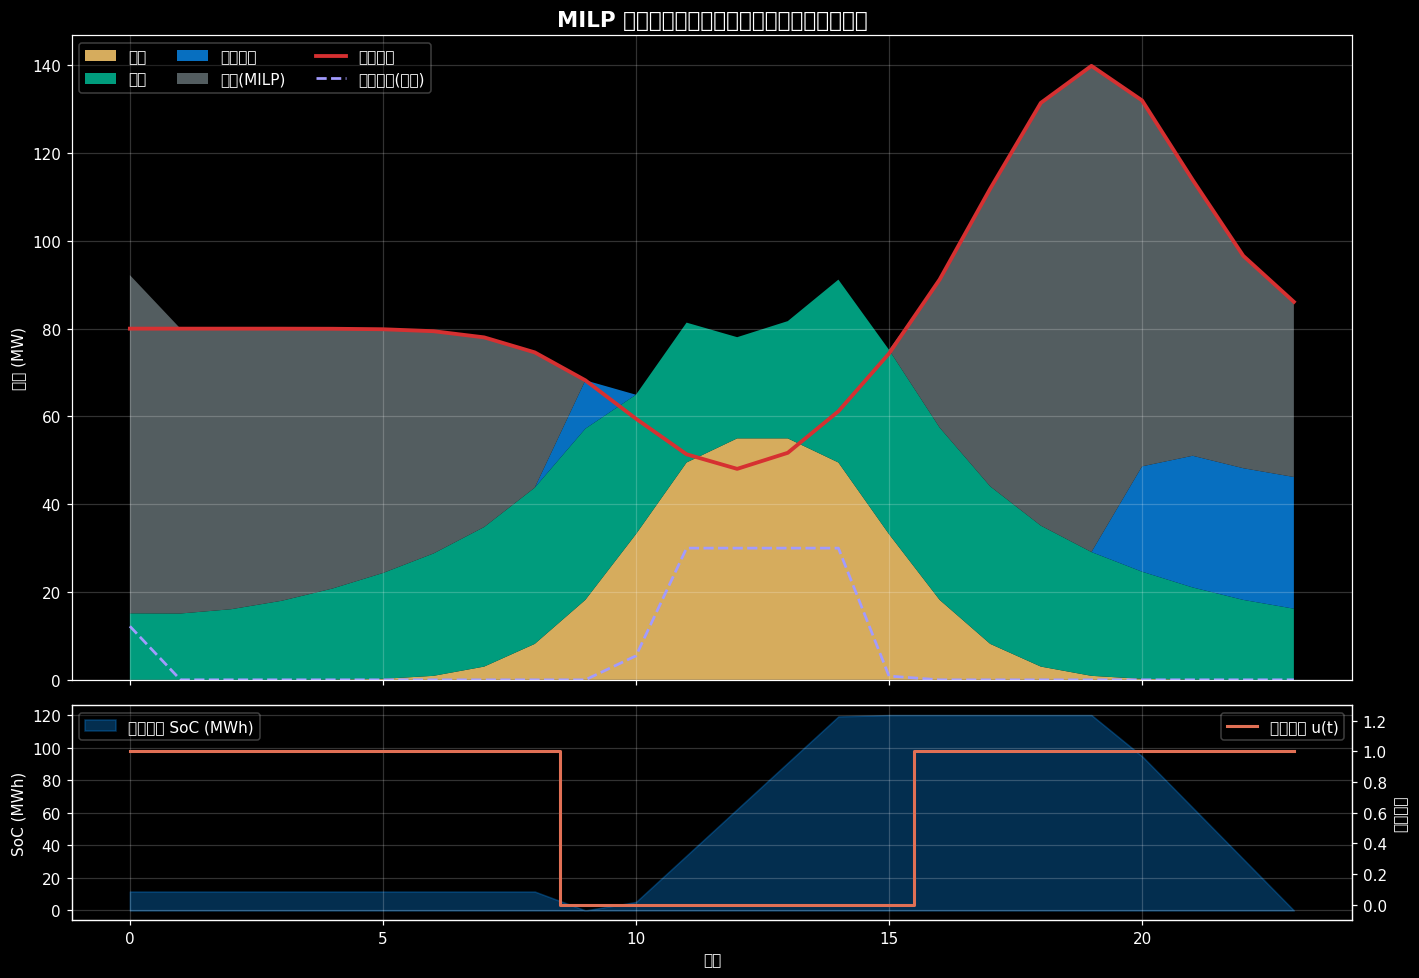

In [3]:
# ---- 可视化：MILP 调度堆叠图 + SoC + 机组启停 ----
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 9), sharex=True,
                               gridspec_kw={"height_ratios": [3, 1]})

# 上层：发电堆叠 (风 + 光 + 放电 + 火电)
ax1.stackplot(
    hours,
    r_milp.solar, r_milp.wind, r_milp.discharge, r_milp.coal,
    labels=["光伏", "风电", "电池放电", "火电(MILP)"],
    colors=["#fdcb6e", "#00b894", "#0984e3", "#636e72"], alpha=0.85,
)
ax1.plot(hours, demand, color="#d63031", linewidth=2.5, label="负荷需求")
ax1.plot(
    hours, r_milp.charge, color="#a29bfe", linewidth=1.8,
    linestyle="--", label="电池充电(消耗)",
)
ax1.set_ylabel("功率 (MW)")
ax1.set_title("MILP 工业级调度：午间盈余充电、傍晚尖峰放电", fontsize=14, fontweight="bold")
ax1.legend(loc="upper left", ncol=3, framealpha=0.3)
ax1.grid(alpha=0.2)

# 下层：电池 SoC + 机组在线状态
ax2.fill_between(hours, 0, r_milp.soc, color="#0984e3", alpha=0.35, label="电池电量 SoC (MWh)")
ax2b = ax2.twinx()
ax2b.step(
    hours, r_milp.commitment, color="#e17055", where="mid",
    linewidth=2, label="火电在线 u(t)",
)
ax2b.set_ylim(-0.1, 1.3)
ax2.set_ylabel("SoC (MWh)")
ax2b.set_ylabel("机组状态")
ax2.set_xlabel("小时")
ax2.legend(loc="upper left", framealpha=0.3)
ax2b.legend(loc="upper right", framealpha=0.3)
ax2.grid(alpha=0.2)

plt.tight_layout()
plt.show()
